# Step 2: Realistic Synthetic Retail POS Analytics
### 90-Day Retail POS Transactions with Dual-Currency Ledger & KHQR / Bakong Payments
**Project:** Cambodia MSE Intelligence  
**Department:** Department of Applied Mathematics and Statistics, Institute of Technology of Cambodia (ITC)  
**Data Generator:** `ingestion/generate_synthetic_pos.py` (Pandas & Faker)  
**Key Operational Realities Simulated:**
1. **Dual-Currency Ledger:** Daily transactions priced in both **USD** and **KHR** with official National Bank of Cambodia (NBC) foreign exchange rate movements.
2. **Payment Types:** Authentic checkout payment method splits (~60–70% via **ABA KHQR / Bakong** QR codes and cash).
3. **Inventory & Customers:** Product SKUs with stock levels, cost prices, lead times, and unique `Customer_ID`s to enable customer tracking and basket analytics.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = os.path.join('..', '..', 'data', 'synthetic_pos')
df_txns = pd.read_parquet(os.path.join(data_dir, 'pos_transactions_90d.parquet'))
df_products = pd.read_csv(os.path.join(data_dir, 'dim_products.csv'))
df_customers = pd.read_csv(os.path.join(data_dir, 'dim_customers.csv'))
df_fx = pd.read_csv(os.path.join(data_dir, 'dim_fx_rates.csv'))

print(f"Total Transactions: {df_txns['transaction_id'].nunique():,} baskets ({len(df_txns):,} line items)")
print(f"Total 90-Day Revenue: ${df_txns['total_amount_usd'].sum():,.2f} USD ({df_txns['total_amount_khr'].sum():,.0f} KHR)")
print(f"Total Customers: {df_customers['customer_id'].nunique():,} profiles")
print(f"Product SKUs: {len(df_products)} across {df_products['category'].nunique()} categories")

Total Transactions: 14,042 baskets (26,002 line items)
Total 90-Day Revenue: $58,974.85 USD (241,051,000 KHR)
Total Customers: 851 profiles
Product SKUs: 34 across 6 categories

### 2.1 Dual-Currency Ledger: Daily Revenue in USD vs. KHR
Transactions are tracked simultaneously in USD and KHR using daily National Bank of Cambodia (NBC) foreign exchange reference rates.

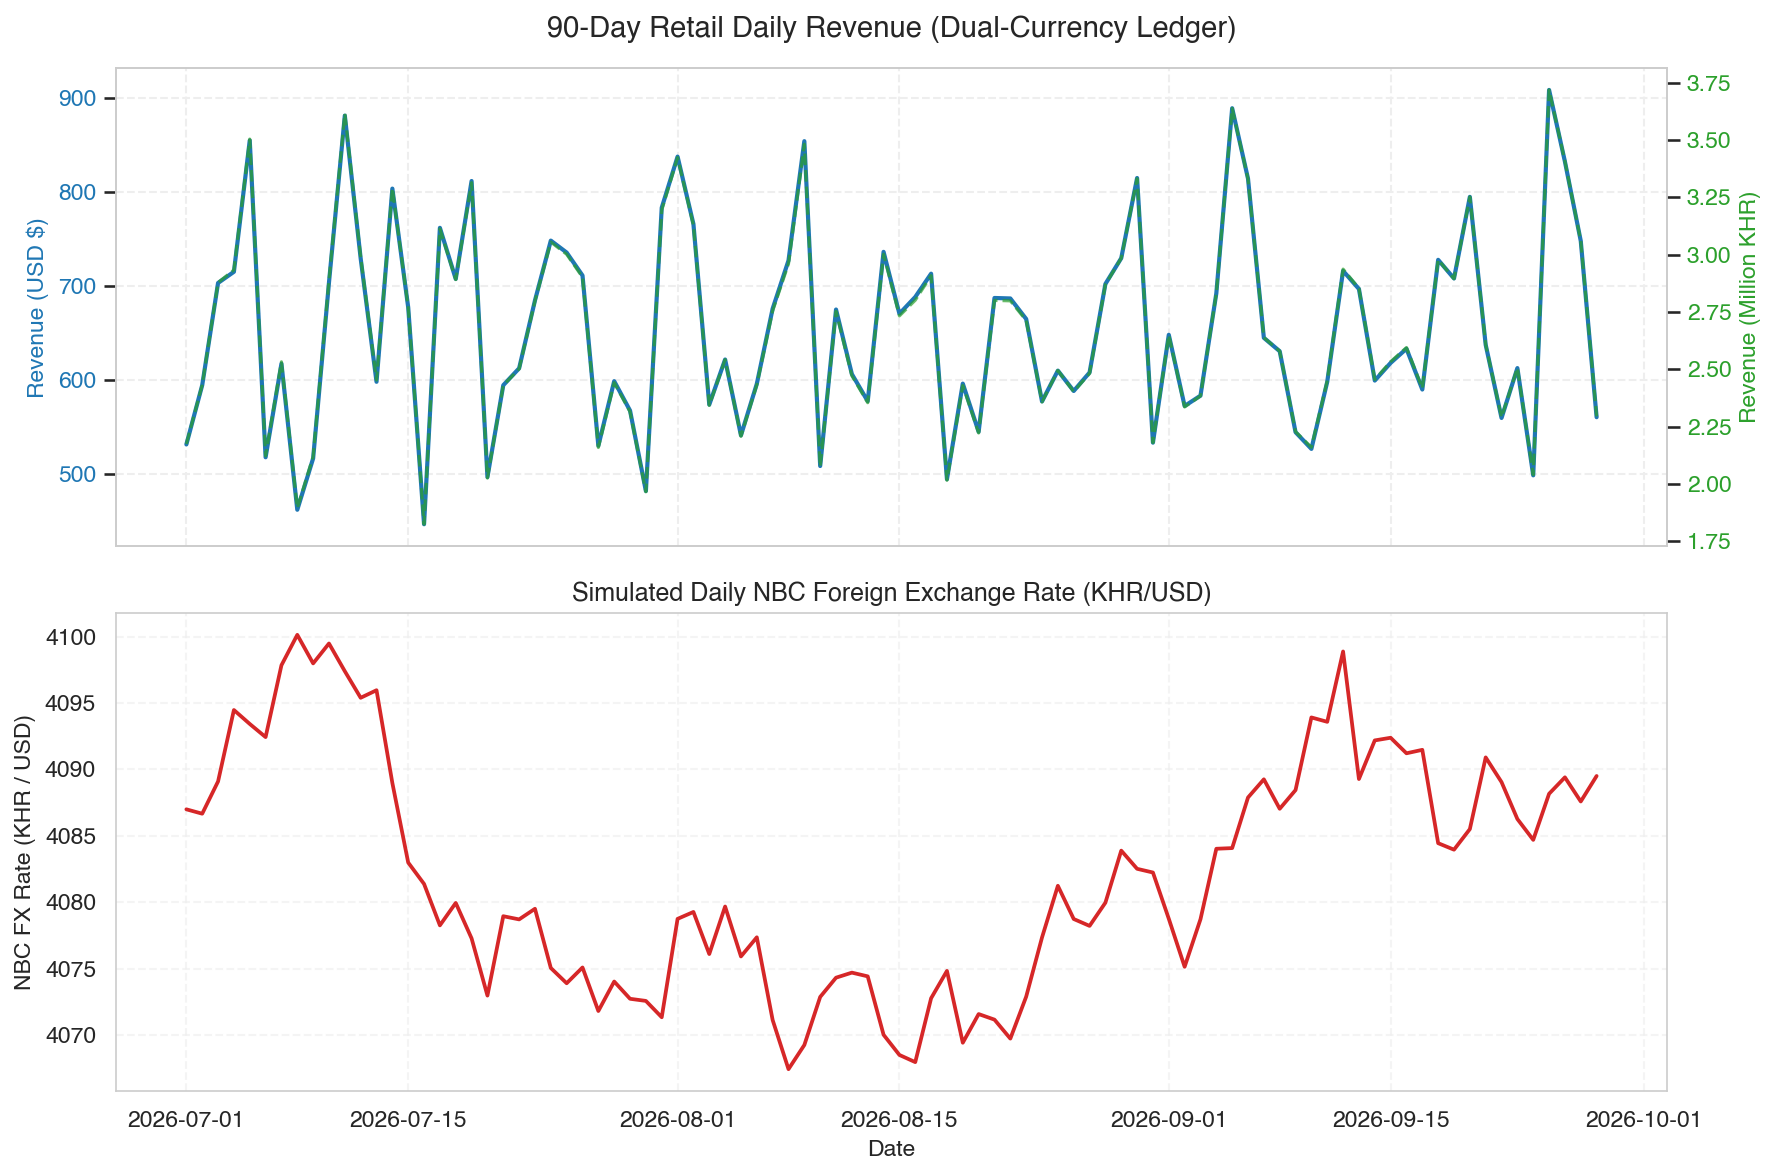

In [ ]:
# Dual-Currency Daily Sales & NBC FX Rate
import matplotlib.pyplot as plt
daily = df_txns.groupby("date").agg({
    "total_amount_usd": "sum",
    "total_amount_khr": "sum",
    "nbc_exchange_rate": "first"
}).reset_index()
daily["date"] = pd.to_datetime(daily["date"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(daily["date"], daily["total_amount_usd"], color="#1f77b4", linewidth=2, label="Daily Sales (USD)")
ax1.set_ylabel("Revenue (USD $)", color="#1f77b4")

ax1_khr = ax1.twinx()
ax1_khr.plot(daily["date"], daily["total_amount_khr"] / 1e6, color="#2ca02c", linestyle="--", label="Daily Sales (Million KHR)")
ax1_khr.set_ylabel("Revenue (Million KHR)", color="#2ca02c")
ax1.set_title("90-Day Retail Daily Revenue (Dual-Currency Ledger)", fontsize=14, fontweight='bold')

ax2.plot(daily["date"], daily["nbc_exchange_rate"], color="#d62728", linewidth=1.8)
ax2.set_ylabel("NBC FX Rate (KHR / USD)")
plt.show()

### 2.2 Payment Method Distribution: ABA KHQR & Bakong QR Dominance
Reflecting local checkout conditions: **57.8% via Digital QR (ABA KHQR & Bakong)**, **34.4% Cash (KHR & USD)**, and **7.8% Card**.

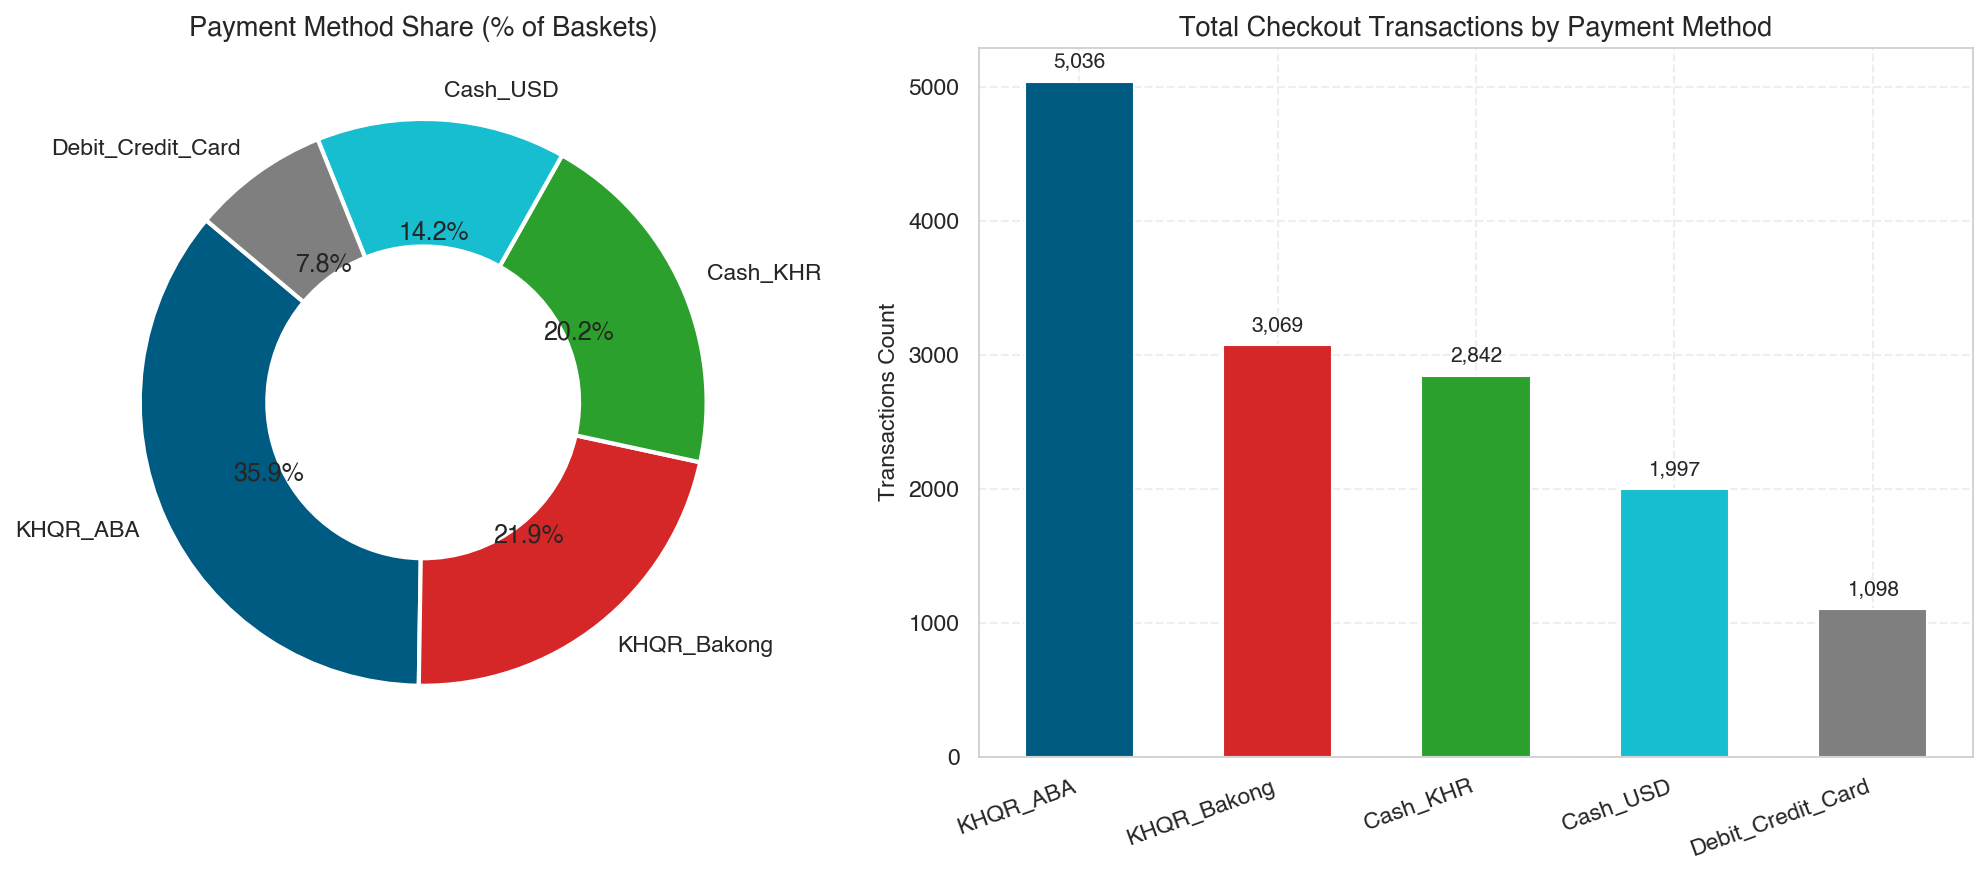

In [ ]:
# Payment Methods Breakdown (ABA KHQR / Bakong / Cash)
import matplotlib.pyplot as plt
txn_payments = df_txns.drop_duplicates(subset=["transaction_id"])["payment_method"].value_counts()
txn_payment_shares = (txn_payments / txn_payments.sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#005b82', '#d62728', '#2ca02c', '#17becf', '#7f7f7f']
ax1.pie(txn_payment_shares, labels=txn_payment_shares.index, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
ax1.set_title("Payment Method Share (% of Baskets)", fontsize=13, fontweight='bold')

bars = ax2.bar(txn_payments.index, txn_payments.values, color=colors, width=0.55)
ax2.set_title("Total Checkout Transactions by Payment Method", fontsize=13, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 100, f"{h:,}", ha='center', fontweight='bold')
plt.show()

### 2.3 Inventory Management: Stock Levels, Reorder Points & Lead Times
Monitoring stock adequacy across product categories to prevent stockouts and manage supplier lead times.

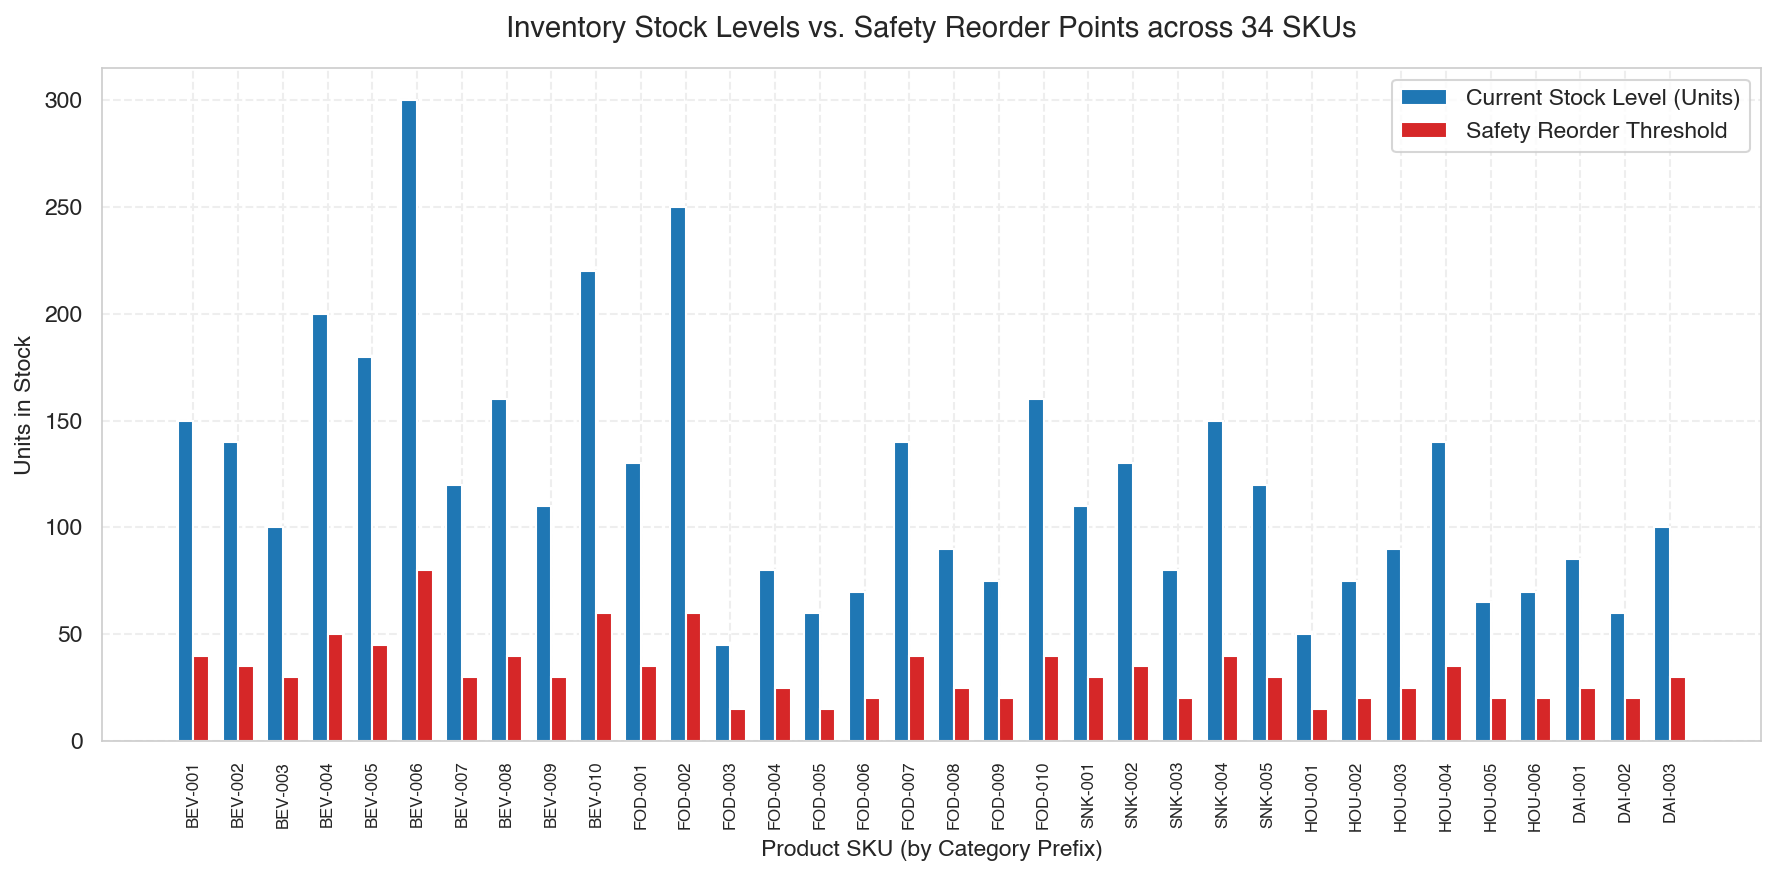

In [ ]:
# Inventory Stock Levels vs Reorder Point
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_products))
w = 0.35
ax.bar(x - w/2, df_products["current_stock_level"], width=w, label="Current Stock Level", color="#1f77b4")
ax.bar(x + w/2, df_products["reorder_point"], width=w, label="Reorder Threshold", color="#d62728")
ax.set_xticks(x)
ax.set_xticklabels([s.replace('SKU-', '') for s in df_products["sku"]], rotation=90)
ax.set_title("Inventory Stock Levels vs. Safety Reorder Points across 34 SKUs", fontsize=14, fontweight='bold')
ax.legend()
plt.show()

### 2.4 Intraday POS Rush Hours (Hourly Distribution)
Identifying the two distinct Cambodian retail foot-traffic peaks: Lunch break (11:00–13:00) and Evening commute (17:00–20:00).

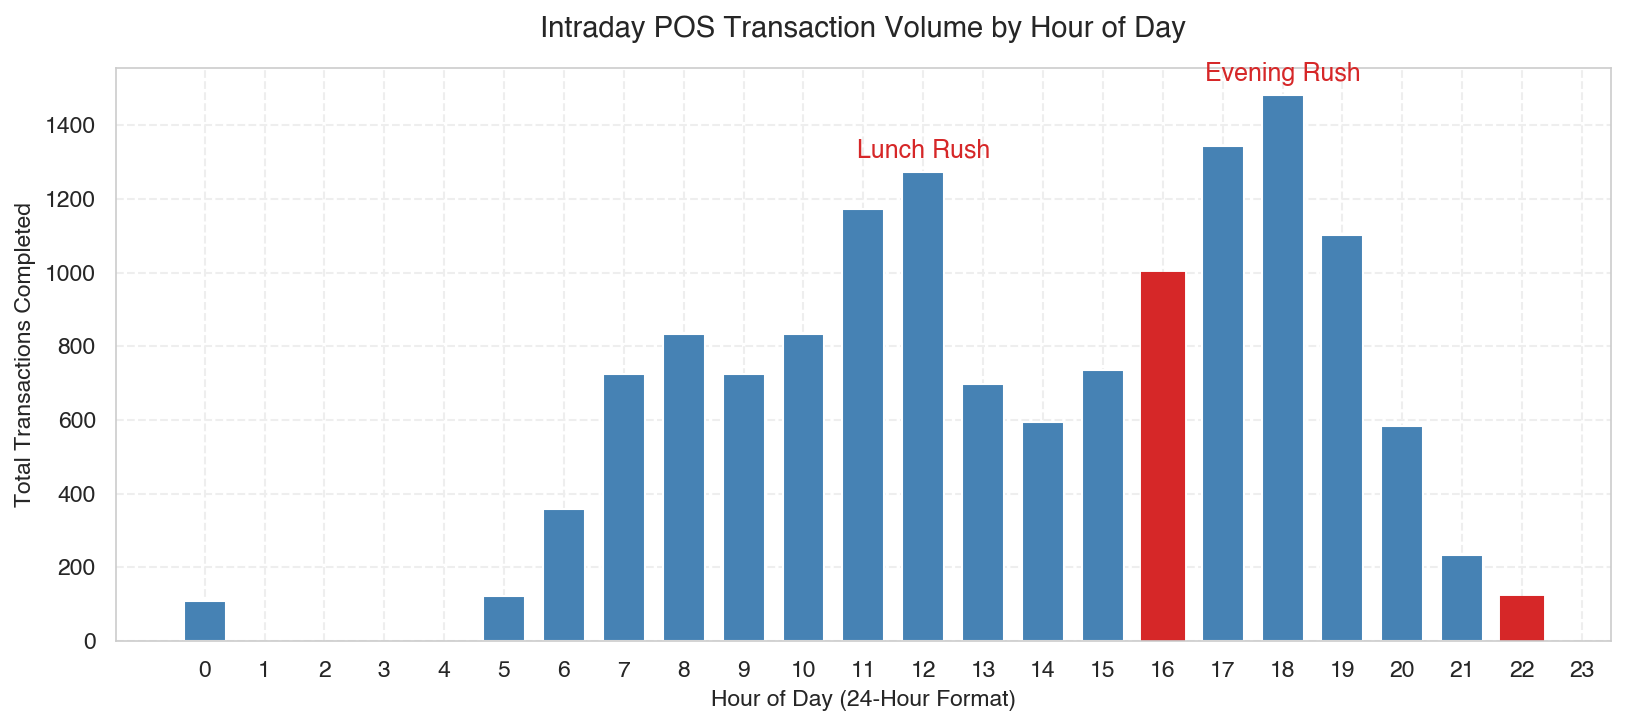

In [ ]:
# Intraday Checkout Rush Hours
import matplotlib.pyplot as plt
hourly = df_txns.drop_duplicates(subset=["transaction_id"])["hour"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(hourly.index, hourly.values, color="#4682b4", width=0.7)
bars[12].set_color("#d62728")
bars[18].set_color("#d62728")
ax.set_title("Intraday POS Transaction Volume by Hour of Day", fontsize=14, fontweight='bold')
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Transactions")
ax.set_xticks(range(24))
plt.show()

### 2.5 Top 10 Revenue-Generating SKUs
Analyzing product velocity and gross margin contribution.

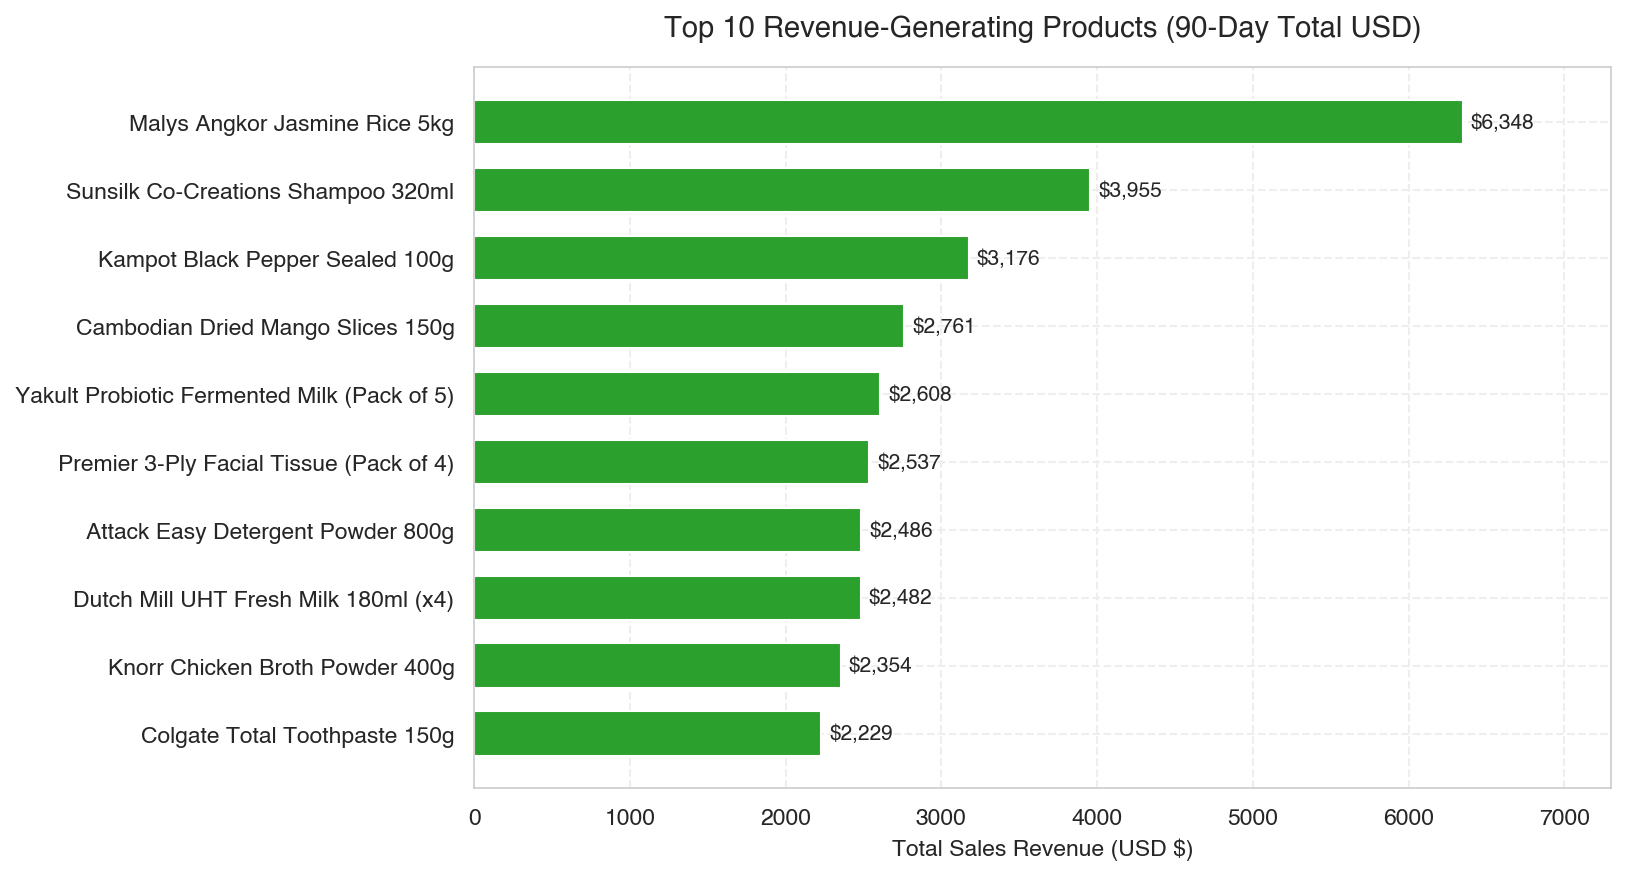

In [ ]:
# Top 10 Revenue SKUs
import matplotlib.pyplot as plt
sku_revenue = df_txns.groupby(["sku", "product_name", "category"]).agg({
    "total_amount_usd": "sum",
    "quantity": "sum",
    "gross_profit_usd": "sum"
}).reset_index().sort_values("total_amount_usd", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(sku_revenue["product_name"], sku_revenue["total_amount_usd"], color="#2ca02c", height=0.65)
ax.set_title("Top 10 Revenue-Generating Products (90-Day Total USD)", fontsize=14, fontweight='bold')
ax.set_xlabel("Sales Revenue ($ USD)")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 50, bar.get_y() + bar.get_height()/2, f"${w:,.0f}", va='center', fontweight='bold')
plt.show()

### Step 2 Strategic Business Insights for Cambodian Retailers
1. **The Cashless Reality (KHQR):** **57.8%** of checkouts occur via **ABA KHQR & Bakong QR**, while physical cash accounts for **34.4%**. Cambodian retail POS systems must treat KHQR dynamic generation as a zero-latency priority.
2. **Dual-Currency Friction:** Over **90%** of inventory purchases from wholesalers are denominated in USD, while a substantial share of consumer cash receipts is in KHR. Managing the NBC conversion spread prevents currency drag on gross margins.
3. **Staffing Optimization:** The two sharp rush periods at **12:00** and **18:00** require retailers to schedule peak staffing and keep multiple QR standees active to prevent checkout bottlenecks.
